## Cognitive Load Estimation Using Physiological Parameters
Using CLAS (Cognitive Load, Affect, and Stress) dataset: https://ieeexplore.ieee.org/abstract/document/8967457

In [1]:
import os
import pandas as pd

In [2]:
# Example: path to participant 1's math test folder
ecg_math_path = "data/participant_1/math_test/"
gsr_math_path = "data/participant_1/math_test/"

ecg_files = [f for f in os.listdir(ecg_math_path) if f.startswith('ecg') and f.endswith('.csv')]
gsr_files = [f for f in os.listdir(gsr_math_path) if f.startswith('gsr') and f.endswith('.csv')]

In [3]:
ecg_data_list = []

for file in ecg_files:
    file_path = os.path.join(ecg_math_path, file)
    df1 = pd.read_csv(file_path)
    ecg_data_list.append(df1)

# Combine into one DataFrame
ecg_combined = pd.concat(ecg_data_list, ignore_index=True)

In [4]:
gsr_data_list = []

for file in gsr_files:
    file_path = os.path.join(gsr_math_path, file)
    df2 = pd.read_csv(file_path)
    gsr_data_list.append(df2)

# Combine into one big DataFrame
gsr_combined = pd.concat(gsr_data_list, ignore_index=True)

In [5]:
print(ecg_combined.head())
print(ecg_combined.shape)

   Timestamp  PythonTimestamp        ecg1       ecg2
0    7624830     1.551792e+09 -605.000072 -14.046336
1    7624958     1.551792e+09 -605.000072 -13.741839
2    7625086     1.551792e+09 -605.000072 -15.621473
3    7625214     1.551792e+09 -605.000072 -17.032893
4    7625342     1.551792e+09 -605.000072 -16.086946
(52213, 4)


### Choosing ECG channel

In [6]:
print(df1.columns)

Index(['Timestamp', 'PythonTimestamp', 'ecg1', 'ecg2'], dtype='object')


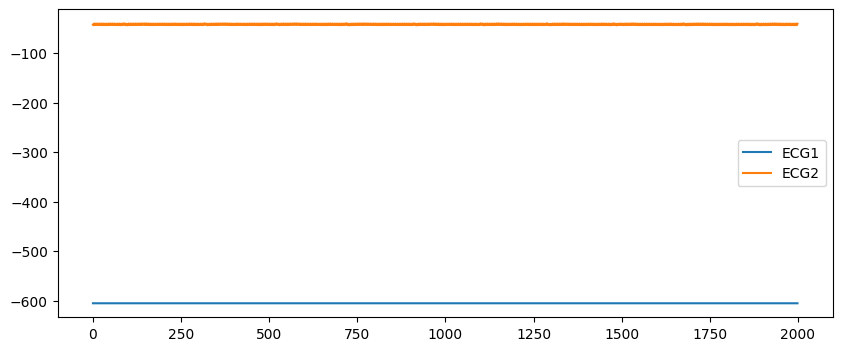

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df1['ecg1'][:2000], label='ECG1')
plt.plot(df1['ecg2'][:2000], label='ECG2')
plt.legend()
plt.show()

In [10]:
df1[['ecg1', 'ecg2']].describe()

,ecg1,ecg2
count,7.687000e+03,7687.000000
mean,-6.050001e+02,-42.117672
std,3.410827e-13,1.169979
min,-6.050001e+02,-44.375428
25%,-6.050001e+02,-43.243768
50%,-6.050001e+02,-42.098477
75%,-6.050001e+02,-40.988092
max,-6.050001e+02,-39.678363


In [11]:
ecg = df1['ecg2']

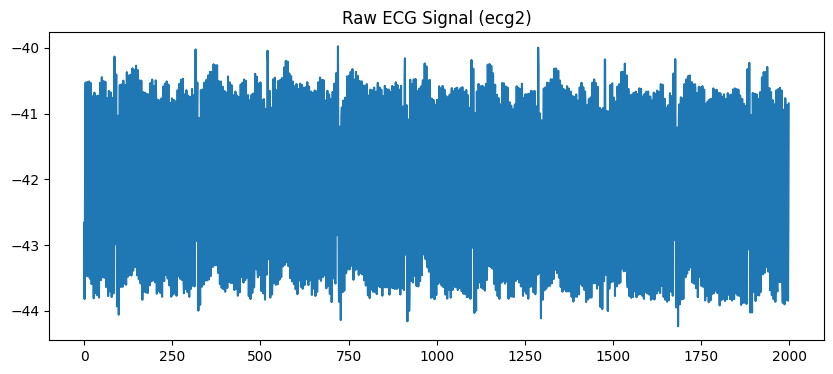

In [12]:
plt.figure(figsize=(10,4))
plt.plot(ecg[:2000])
plt.title("Raw ECG Signal (ecg2)")
plt.show()

In [13]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Bandpass Filter to remove noise ---
def bandpass_filter(signal, lowcut=0.5, highcut=45, fs=256, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

filtered_ecg = bandpass_filter(ecg)

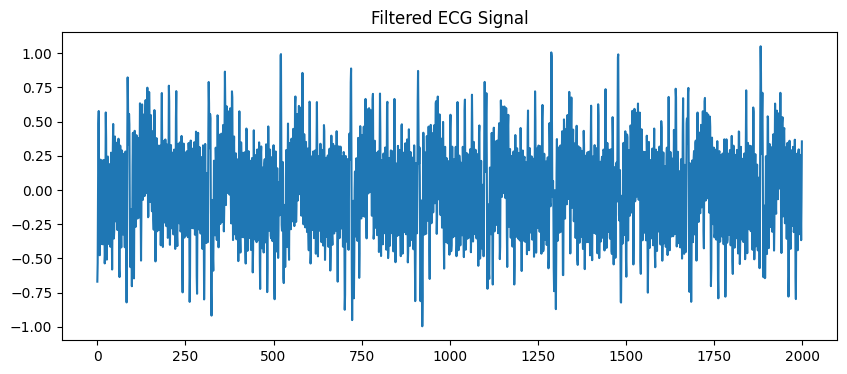

In [14]:
# --- Step 2: Plot filtered signal ---
plt.figure(figsize=(10,4))
plt.plot(filtered_ecg[:2000])
plt.title("Filtered ECG Signal")
plt.show()

In [15]:
!pip install biosppy


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
!pip install peakutils


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


used for detecting and characterizing peaks in one-dimensional data, such as signals and time series

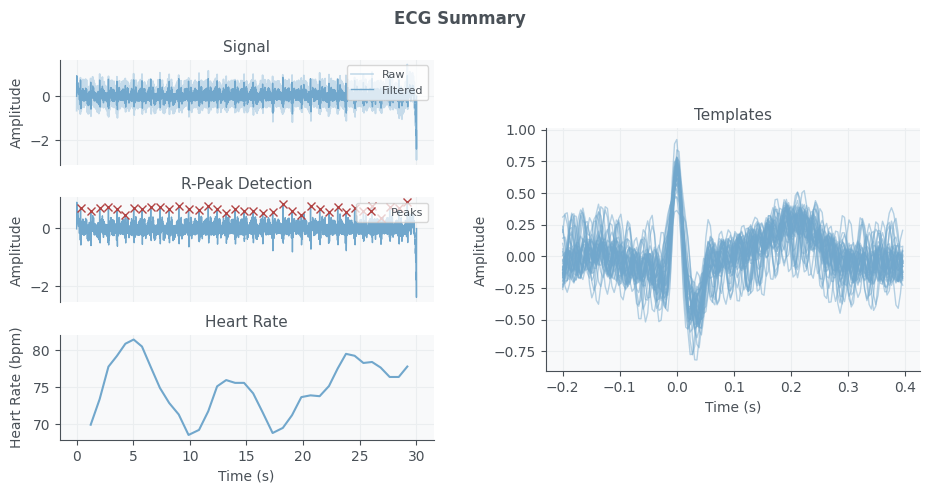

In [18]:
# Detect R-peaks and Extract Basic Info
from biosppy.signals import ecg

out = ecg.ecg(signal=filtered_ecg, sampling_rate=256, show=True)

In [19]:
import numpy as np

# R-peak indices
rpeaks = out['rpeaks']

# RR intervals (in seconds)
rr_intervals = np.diff(rpeaks) / 256.0

# Heart rate (in beats per minute)
heart_rate = 60 / rr_intervals

# Basic features
mean_hr = np.mean(heart_rate)
std_hrv = np.std(rr_intervals)   # HRV (SDNN)

print(f"Mean Heart Rate: {mean_hr:.2f} bpm")
print(f"HRV (SDNN): {std_hrv:.4f} sec")

Mean Heart Rate: 75.09 bpm
HRV (SDNN): 0.0474 sec


Processing gsr signal

In [20]:
print(gsr_combined.head())

   Timestamp  PythonTimestamp  accelx  accely  accelz          ppg         gsr
0   10069943     1.551792e+09    2027    2839    2110  1467.399267  106.600000
1   10070071     1.551792e+09    2024    2839    2111  1475.457875  106.600000
2   10070199     1.551792e+09    2027    2838    2111  1483.516484  106.542018
3   10070327     1.551792e+09    2028    2836    2108  1490.842491  106.542018
4   10070455     1.551792e+09    2028    2832    2106  1497.435897  106.542018


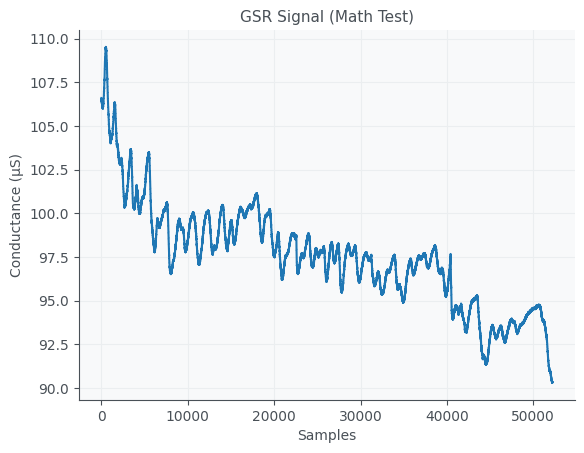

In [21]:
import matplotlib.pyplot as plt

plt.plot(gsr_combined['gsr'])
plt.title("GSR Signal (Math Test)")
plt.xlabel("Samples")
plt.ylabel("Conductance (µS)")
plt.show()

In [22]:
gsr_signal = gsr_combined['gsr'].values

mean_gsr = np.mean(gsr_signal)
std_gsr = np.std(gsr_signal)
min_gsr = np.min(gsr_signal)
max_gsr = np.max(gsr_signal)
range_gsr = max_gsr - min_gsr

print(f"Mean GSR: {mean_gsr:.4f}")
print(f"Std GSR: {std_gsr:.4f}")
print(f"Range GSR: {range_gsr:.4f}")

Mean GSR: 97.5495
Std GSR: 3.0250
Range GSR: 19.2336


In [ ]:
merged_df = pd.merge(filtered_ecg, gsr_signal, on='time_window')